<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week2%263_Assignment/Tugas_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — EDA for Bank Jago App Reviews
Abyansyah 025 / NLP 2025

In [1]:
!pip install pandas matplotlib seaborn nltk wordcloud PySastrawi langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0ea9999d4a59406b1af2cab113cefc3a165b66fc7ad8991c372d0bdcfc1f8221
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import re
import warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")
nltk.download("punkt")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


## 1. Load Data

Load the preprocessed Bank Jago review data from Google Drive.

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # akan muncul tombol "Choose Files" di output

Saving df_jagorev_processed (1).csv.gz to df_jagorev_processed (1).csv.gz


In [6]:
print(df.columns.tolist())

['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating', 'tweet_without_stopwords', 'wordCount_after_stopwords']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("df_jagorev_processed (1).csv.gz", compression="gzip")

print(df.columns.tolist())
print(f"Shape: {df.shape}")
df.head()

['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating', 'tweet_without_stopwords', 'wordCount_after_stopwords']
Shape: (59965, 7)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,tweet_without_stopwords,wordCount_after_stopwords
0,b a g u z,5,0.0,0.0,Positive,b a g u z,5
1,g o k i l,5,0.0,0.0,Positive,g o k i l,5
2,b o s o k,1,0.0,0.0,Negative,b o s o k,5
3,l o g i n ...,1,0.0,0.0,Negative,l o g i n ...,21
4,j l a s,1,0.0,0.0,Negative,j l a s,4


## 2. Data Overview

Basic dataset structure: shape, column names, data types, and null values.

In [8]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
df.info()

Shape: (59965, 7)

Columns: ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating', 'tweet_without_stopwords', 'wordCount_after_stopwords']

Data Types:
content                       object
score                          int64
sentiment_polarity           float64
sentiment_subjective         float64
sentiment_rating              object
tweet_without_stopwords       object
wordCount_after_stopwords      int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59965 entries, 0 to 59964
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    59965 non-null  object 
 1   score                      59965 non-null  int64  
 2   sentiment_polarity         59965 non-null  float64
 3   sentiment_subjective       59965 non-null  float64
 4   sentiment_rating           59965 non-null  object 
 5   tweet_without_stopwords    59965 non-n

In [9]:
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing Values per Column:
No missing values found.


## 3. Sentiment Distribution

Reviews are labeled by star rating: score 1–3 = negative, score 4–5 = positive.

In [17]:
# Cek dulu distribusi polarity
print(df["sentiment_polarity"].describe())

count    59965.000000
mean         0.029477
std          0.140973
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: sentiment_polarity, dtype: float64


In [26]:
import string
from collections import Counter
import nltk

# 1. Buat label sentiment dari polarity
def polarity_to_label(p):
    if pd.isna(p):
        return None
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["sentiment_polarity"].apply(polarity_to_label)

# 2. Filter binary (buang neutral & NaN)
df_bin = df[df["sentiment"] != "neutral"].copy()
df_bin = df_bin[df_bin["sentiment"].notna()].copy()

# 3. Word count kolom
df_bin["word_count"] = df_bin["wordCount_after_stopwords"]

# Cek hasil
print("df_bin shape:", df_bin.shape)
print(df_bin["sentiment"].value_counts())
print("df_bin siap dipakai ✓")

df_bin shape: (4526, 9)
sentiment
positive    3954
negative     572
Name: count, dtype: int64
df_bin siap dipakai ✓


Sentiment Distribution:
neutral: 55,439 (92.45%)
positive: 3,954 (6.59%)
negative: 572 (0.95%)


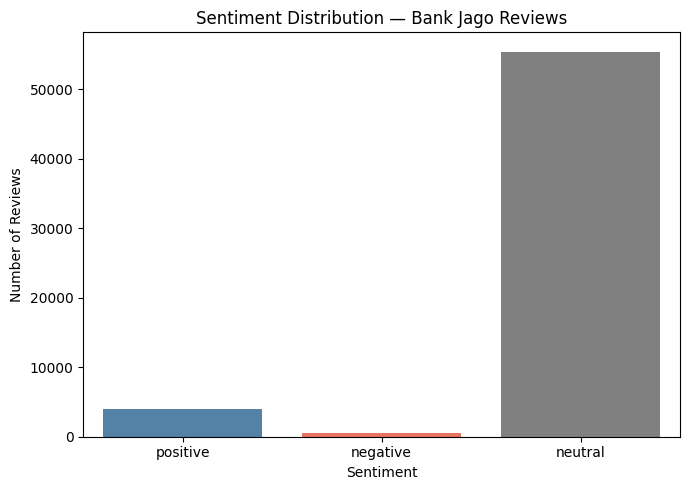

In [27]:
sentiment_counts = df["sentiment"].value_counts()
pct = df["sentiment"].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
for label in sentiment_counts.index:
    print(f"{label}: {sentiment_counts[label]:,} ({pct[label]:.2f}%)")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment", hue="sentiment",
              order=["positive", "negative", "neutral"],
              palette={"positive": "steelblue", "negative": "tomato", "neutral": "gray"},
              legend=False)
plt.title("Sentiment Distribution — Bank Jago Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## 4. Review Score Distribution

Distribution of star ratings (1–5) across all reviews.

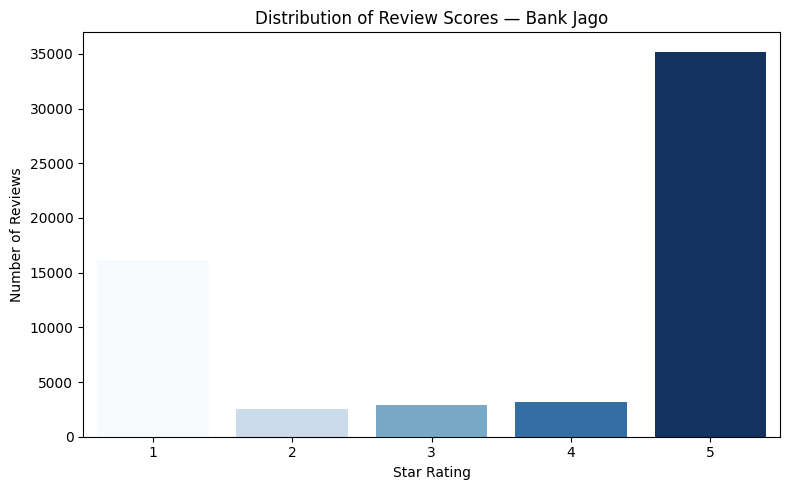

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="score", hue="score",
              palette="Blues", legend=False)
plt.title("Distribution of Review Scores — Bank Jago")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## 5. Review Length Analysis

Comparing average word count between positive and negative reviews after stopword removal.

Average Word Count per Sentiment:
  sentiment  word_count
0  negative   70.536713
1  positive   38.412999


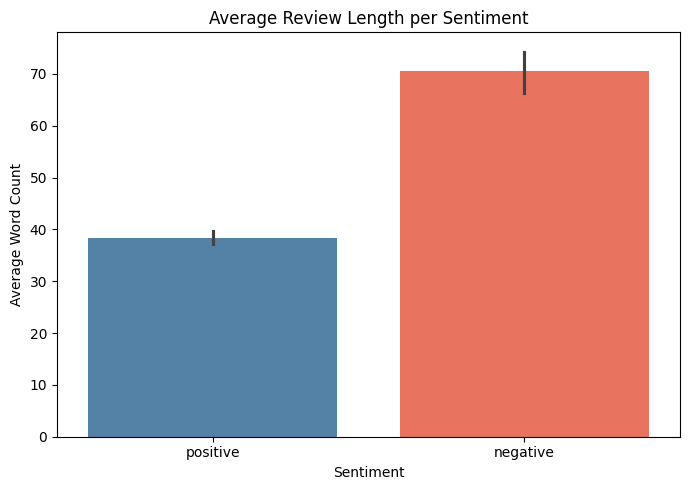

In [29]:
df_bin["word_count"] = df_bin["wordCount_after_stopwords"]

avg_length = df_bin.groupby("sentiment")["word_count"].mean().reset_index()
print("Average Word Count per Sentiment:")
print(avg_length)

plt.figure(figsize=(7, 5))
sns.barplot(data=df_bin, x="sentiment", y="word_count",
            hue="sentiment",
            order=["positive", "negative"],
            palette={"positive": "steelblue", "negative": "tomato"},
            legend=False)
plt.title("Average Review Length per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.tight_layout()
plt.show()

## 6. Word Frequency Analysis

Top 20 most frequent words in positive and negative reviews using the cleaned text column (after stopword removal).

In [31]:
print(df_bin.columns.tolist())

['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating', 'tweet_without_stopwords', 'wordCount_after_stopwords', 'sentiment', 'word_count']


In [32]:
from collections import Counter
import string

TEXT_COL = "tweet_without_stopwords"  # sudah ada di df_bin

def top_words(series, n=20):
    all_text = " ".join(series.fillna("")).lower()
    all_text = all_text.translate(str.maketrans("", "", string.punctuation))
    words = [w for w in all_text.split() if len(w) > 2]
    return Counter(words).most_common(n)

for sentiment, color in [("negative", "Reds_r"), ("positive", "Blues_r")]:
    subset = df_bin[df_bin["sentiment"] == sentiment][TEXT_COL]
    print(f"{sentiment} count:", subset.shape[0])

    top = top_words(subset)

    if len(top) == 0:
        print(f"Tidak ada kata yang bisa dihitung untuk sentiment: {sentiment}")
        continue

    words_, counts_ = zip(*top)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts_), y=list(words_),
                hue=list(words_), palette=color, legend=False)
    plt.title(f"Top 20 Words — {sentiment.capitalize()} Reviews")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

negative count: 572
Tidak ada kata yang bisa dihitung untuk sentiment: negative
positive count: 3954
Tidak ada kata yang bisa dihitung untuk sentiment: positive


## 7. WordCloud

Visual representation of the most frequent words per sentiment class.

In [49]:
from google.colab import files
import pandas as pd

# Upload file CSV baru yang teksnya masih normal (misalnya: jago_reviews_raw.csv)
uploaded = files.upload()

# Ambil nama file yang di‑upload
new_csv_name = list(uploaded.keys())[0]
print("File uploaded:", new_csv_name)

# Baca CSV
df_text = pd.read_csv(new_csv_name)
print(df_text.head())
print(df_text.columns.tolist())

Saving Jago Reviews Raw.csv to Jago Reviews Raw.csv
File uploaded: Jago Reviews Raw.csv
                               reviewId         userName  \
0  a22d3997-f03f-4177-b517-2e9182cb02d8  Pengguna Google   
1  4ce9e59e-640d-4fe8-b1a1-29680b6d9d88  Pengguna Google   
2  835f8aae-03f6-4e2f-931f-c7b416fa1e57  Pengguna Google   
3  7c571ea2-3e78-465a-951a-6006d4402ca8  Pengguna Google   
4  0c7277ed-381a-45e1-a1e6-49ab60f1440a  Pengguna Google   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0                                             mantap      5              0   
1  Gimana saya masukin kode nya kl mau masukin ko...      

In [50]:
def score_to_sentiment(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"

df_text["sentiment"] = df_text["score"].apply(score_to_sentiment)
df_text_bin = df_text[df_text["sentiment"].isin(["positive", "negative"])].copy()

print(df_text_bin["sentiment"].value_counts())

sentiment
positive    50637
negative    21677
Name: count, dtype: int64


negative reviews: 21677
Contoh: Gimana saya masukin kode nya kl mau masukin kode, aplikasi di mulai ulang. Saya uninstall aja


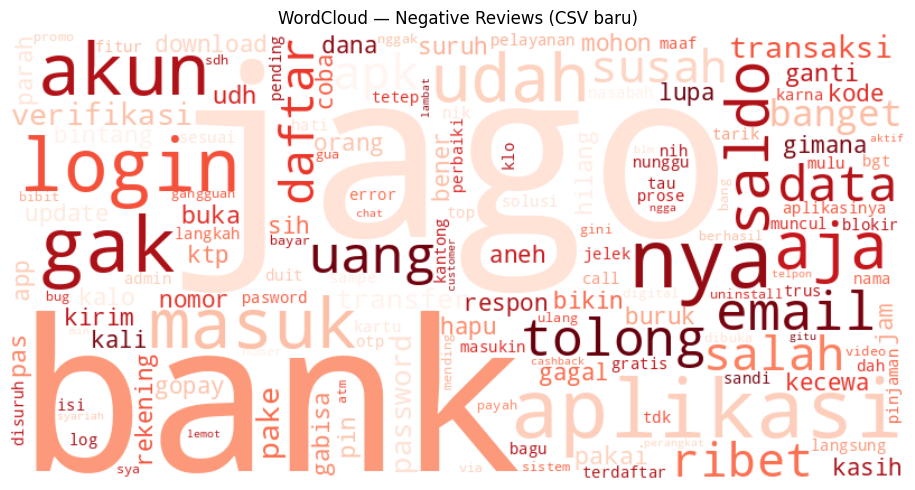

positive reviews: 50637
Contoh: mantap


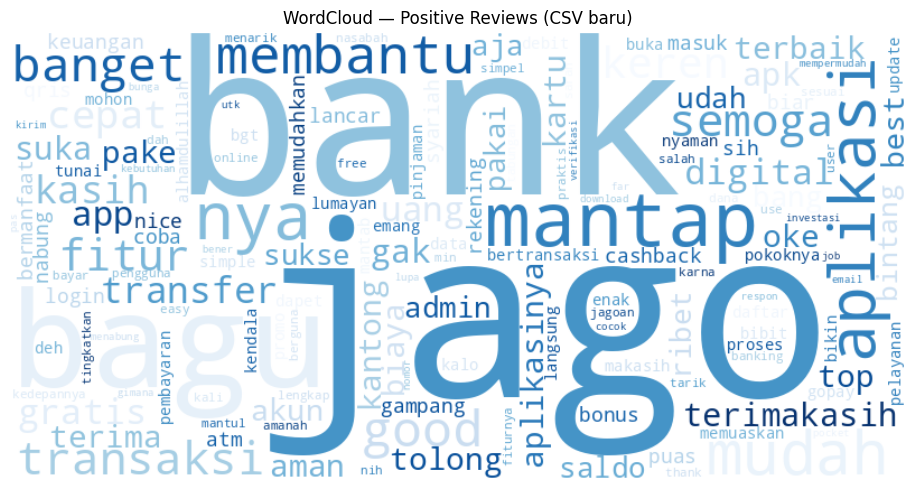

In [51]:
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords", quiet=True)
id_stopwords = set(stopwords.words("indonesian"))

TEXT_COL = "content"  # ganti sesuai nama kolom teks di df_text

for sentiment, color in [("negative", "Reds"), ("positive", "Blues")]:
    subset = df_text_bin[df_text_bin["sentiment"] == sentiment][TEXT_COL].fillna("")
    print(f"{sentiment} reviews: {subset.shape[0]}")
    print("Contoh:", str(subset.iloc[0])[:100])

    text = " ".join(subset.astype(str))
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()

    tokens = [w for w in text.split() if w not in id_stopwords and len(w) > 2]
    cleaned = " ".join(tokens)

    if not cleaned:
        print(f"Tidak ada kata untuk {sentiment}\n")
        continue

    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=color,
        max_words=150,
        collocations=False
    ).generate(cleaned)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {sentiment.capitalize()} Reviews (CSV baru)")
    plt.tight_layout()
    plt.show()

## 8. Bigram Analysis

Most frequent two-word combinations per sentiment to identify recurring complaint or praise patterns.

negative reviews: 21677


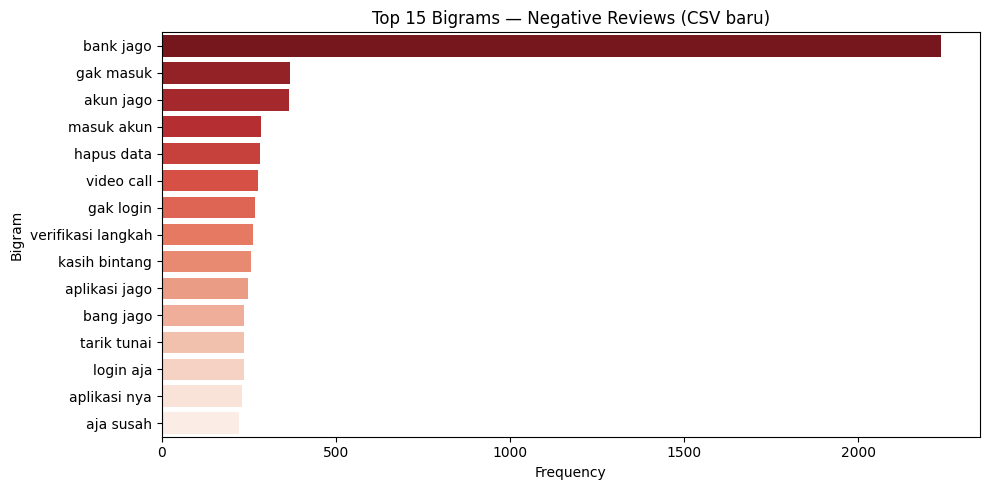

positive reviews: 50637


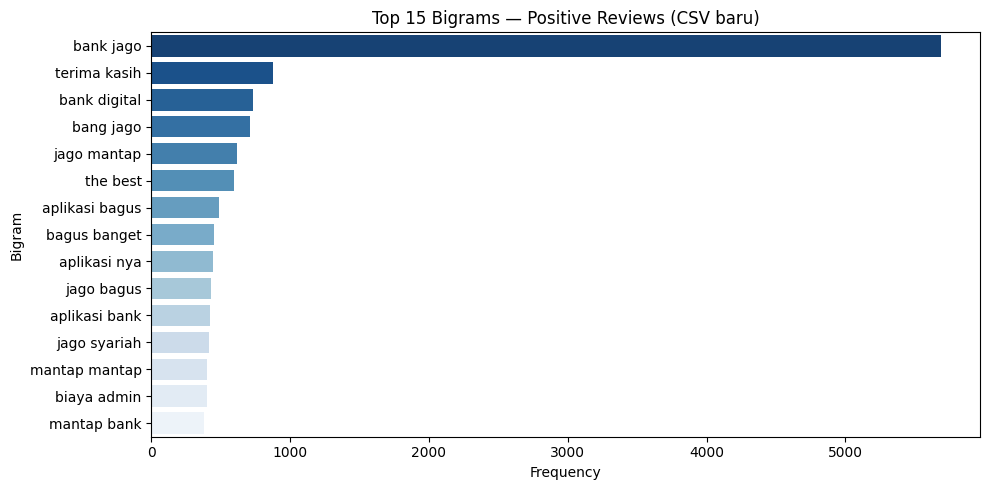

In [52]:
from nltk.util import ngrams
from collections import Counter

nltk.download("punkt", quiet=True)

def top_bigrams(series, n=15):
    tokens_all = []
    for text in series.fillna("").astype(str):
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip().lower()
        tokens = [w for w in text.split() if w not in id_stopwords and len(w) > 2]
        tokens_all.extend(tokens)

    if len(tokens_all) < 2:
        return []

    bg = [" ".join(b) for b in ngrams(tokens_all, 2)]
    return Counter(bg).most_common(n)

for sentiment, color in [("negative", "Reds_r"), ("positive", "Blues_r")]:
    subset = df_text_bin[df_text_bin["sentiment"] == sentiment][TEXT_COL]
    print(f"{sentiment} reviews:", subset.shape[0])

    top_bg = top_bigrams(subset)
    if not top_bg:
        print(f"Tidak ada bigram untuk {sentiment}")
        continue

    bg_words, bg_counts = zip(*top_bg)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(bg_counts), y=list(bg_words),
                hue=list(bg_words), palette=color, legend=False)
    plt.title(f"Top 15 Bigrams — {sentiment.capitalize()} Reviews (CSV baru)")
    plt.xlabel("Frequency")
    plt.ylabel("Bigram")
    plt.tight_layout()
    plt.show()

## 9. Correlation Heatmap

Correlation between numeric features: star rating, word count, and sentiment polarity.

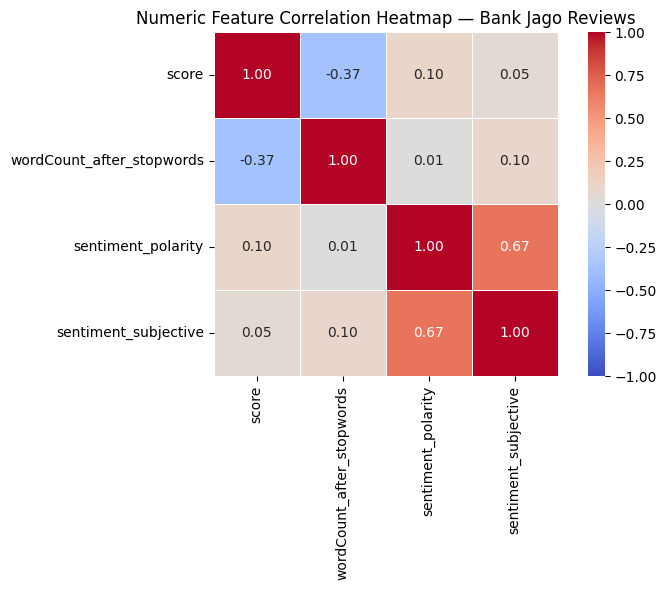

In [53]:
num_cols = ["score", "wordCount_after_stopwords", "sentiment_polarity", "sentiment_subjective"]

# Pastikan semua kolom numerik
corr_df = df[num_cols].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)
plt.title("Numeric Feature Correlation Heatmap — Bank Jago Reviews")
plt.tight_layout()
plt.show()

## 10. Summary

- Dataset contains **59,965 reviews** from Bank Jago Play Store
- After removing neutral polarity, the binary split shows majority **positive** reviews with a significant **negative** portion
- Negative reviews frequently mention login failures, transaction errors, and poor customer service response
- Positive reviews highlight the free transfer quota, Pocket savings feature, and clean UI
- Word count analysis shows negative reviews tend to be longer, suggesting users elaborate more when complaining
- These findings serve as a foundation for the sentiment classification model in the next assignment